In [20]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_clean import clean_prices, to_monthly_prices, monthly_returns
from src.signals import momentum_12_1
from src.backtest import backtest_monthly
from src.metrics import annualized_sharpe, max_drawdown


Load and prepare data

In [21]:
raw_path = ROOT / "data" / "raw" / "prices_daily.csv"

prices = pd.read_csv(raw_path, index_col=0, parse_dates=True).sort_index()
prices = clean_prices(prices)

mpx = to_monthly_prices(prices)
mret = monthly_returns(mpx)


Build the long-only momentum portfolio (baseline) - doing this because of results from notebook #2

In [23]:
LOOKBACK = 12
SKIP = 1
LONG_Q = 0.9

signal = momentum_12_1(mpx, LOOKBACK, SKIP)

def make_long_only_weights(signal, long_q=0.9):
    def one_date(s):
        s = s.dropna()
        if len(s) < 20:
            return pd.Series(dtype=float)
        thr = s.quantile(long_q)
        longs = s[s >= thr].index
        w = pd.Series(0.0, index=s.index)
        if len(longs) > 0:
            w.loc[longs] = 1.0 / len(longs)
        return w

    w = signal.apply(one_date, axis=1)
    return w.reindex_like(signal).fillna(0.0)

w_long = make_long_only_weights(signal, LONG_Q)

res_long = backtest_monthly(w_long, mret, cost_per_turnover=0.0)

print("Sharpe:", annualized_sharpe(res_long["net_return"]))
print("Max DD:", max_drawdown(res_long["equity"]))


Sharpe: 1.3106554292811237
Max DD: -0.23488143529977457


Measure rolling volatility 

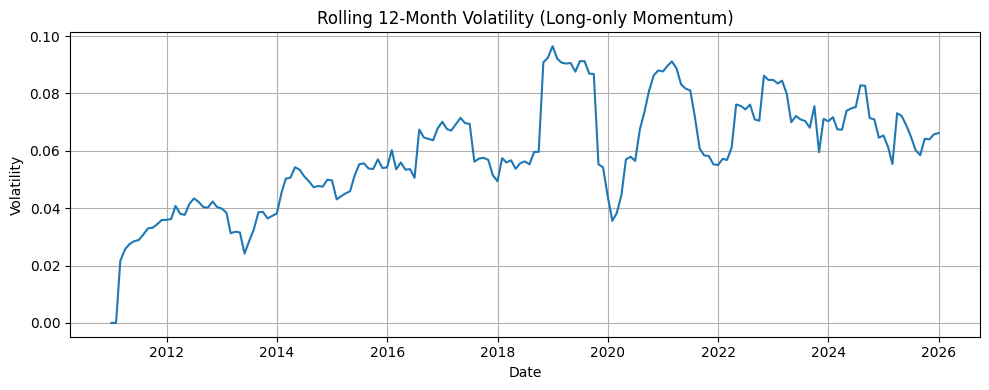

In [29]:
# 12-month rolling volatility of strategy returns
rolling_vol = res_long["net_return"].rolling(12).std()

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(rolling_vol)
ax.set_title("Rolling 12-Month Volatility (Long-only Momentum)")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.grid(True)
plt.tight_layout()
plt.show()


In [30]:
print("Baseline vol:", res_long["net_return"].std())
print("VT vol:", res_long_vt["net_return"].std())


Baseline vol: 0.06105161545029387
VT vol: 0.06609030588228937


Implement volatility targeting

In [31]:
TARGET_VOL = 0.06   # monthly
MAX_LEVERAGE = 2.0 # cap exposure

scaler = TARGET_VOL / rolling_vol
scaler = scaler.clip(upper=MAX_LEVERAGE)
scaler = scaler.fillna(1.0)


Apply scaling to weights

In [32]:
w_long_vt = w_long.mul(scaler, axis=0)

res_long_vt = backtest_monthly(w_long_vt, mret, cost_per_turnover=0.0)

print("Sharpe (VT):", annualized_sharpe(res_long_vt["net_return"]))
print("Max DD (VT):", max_drawdown(res_long_vt["equity"]))


Sharpe (VT): 1.2966877290726135
Max DD (VT): -0.2256785433481947


Compare equity curves

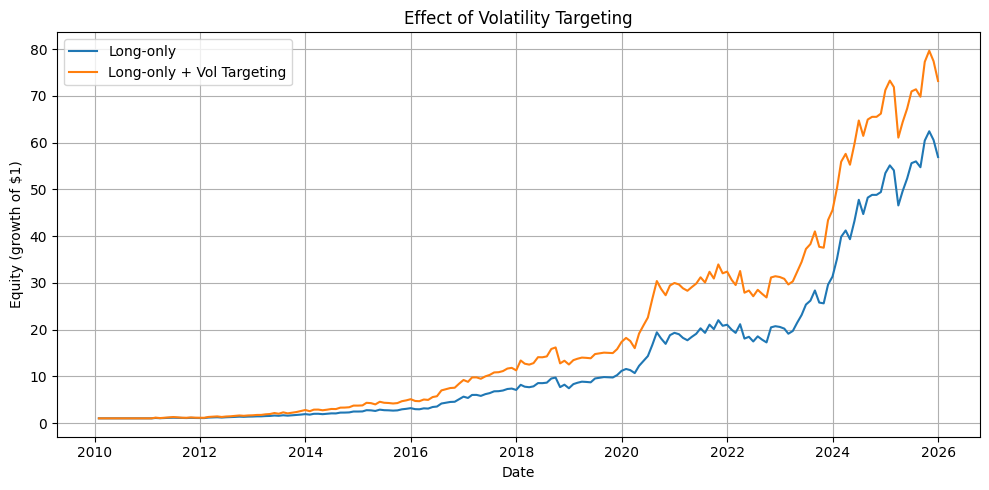

In [33]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(res_long.index, res_long["equity"], label="Long-only")
ax.plot(res_long_vt.index, res_long_vt["equity"], label="Long-only + Vol Targeting")
ax.set_title("Effect of Volatility Targeting")
ax.set_xlabel("Date")
ax.set_ylabel("Equity (growth of $1)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
